<a href="https://colab.research.google.com/github/tb12tilly-eng/PHSX_221-Lab/blob/main/Lab_3_Brady_Johnson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

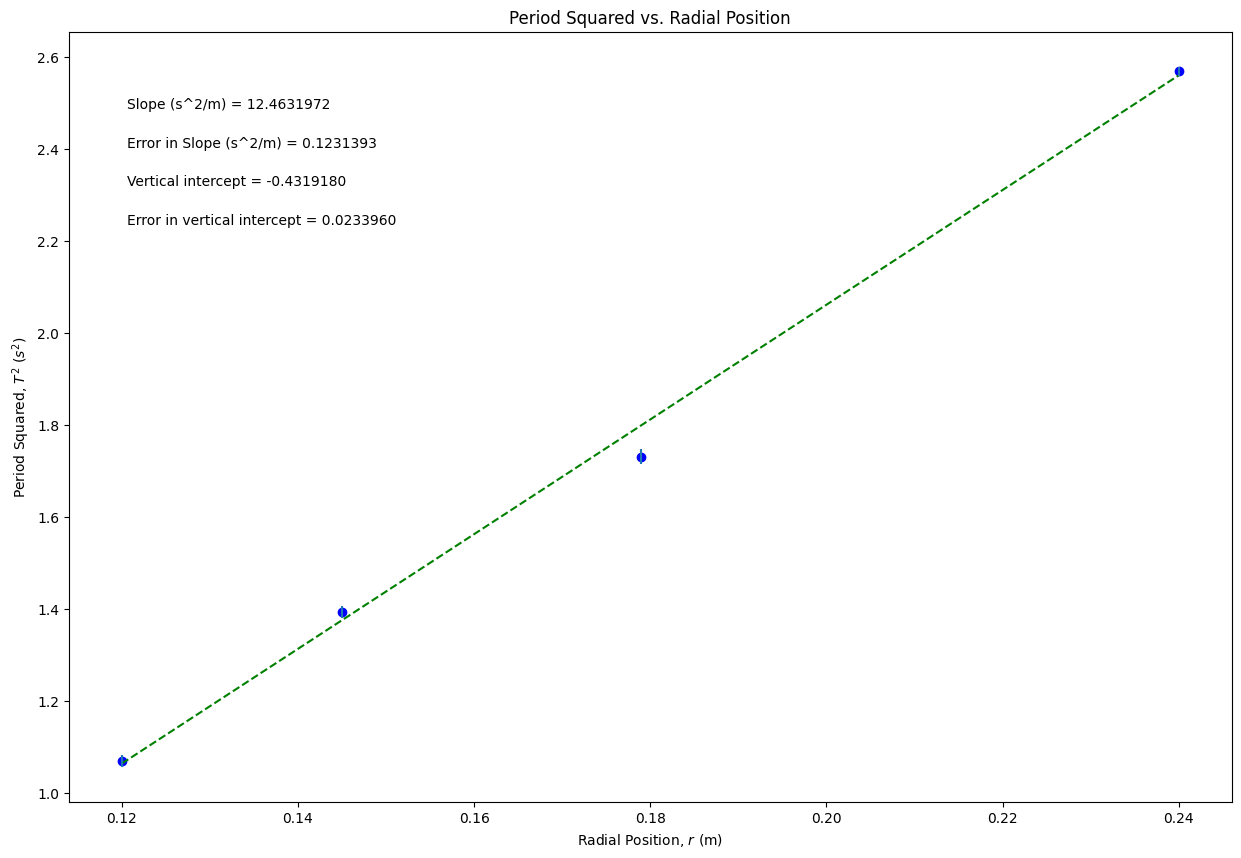

In [1]:
# PHSX 221 & 223 plotting code
# Brady Johnson - Lab 3: Uniform Circular Motion
# Updated September 2026

%matplotlib inline
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt

#-----------------------------------------------------------------------#
#----------DATA INPUT SECTION----------

# x-axis data: Radial position r (m)
radial_position = np.array([0.12, 0.145, 0.179, 0.240])

# y-axis data: Period squared T^2 (s^2) and its uncertainty dT^2
t_squared_data = np.array([1.069983, 1.393816, 1.730803, 2.568327])
t_squared_err  = np.array([0.01319174, 0.01298875, 0.01675725, 0.0097007])

x = radial_position
y = t_squared_data
dy = t_squared_err

plot_title = 'Period Squared vs. Radial Position'
x_label = 'Radial Position, $r$ (m)'
y_label = 'Period Squared, $T^2$ ($s^2$)'
slope_units = 's^2/m'

annotation_placement = 2

#-----------------------------------------------------------------------#
#-----TEMPLATE ALGEBRA MATRICES-----

b, m = np.polynomial.polynomial.polyfit(x, y, 1, w=1/dy)
fit = b + m * x

def Delta(x, dy):
    D = (sum(1 / dy**2)) * (sum(x**2 / dy**2)) - (sum(x / dy**2))**2
    return D

D = Delta(x, dy)
dm = np.sqrt(1 / D * sum(1 / dy**2))
db = np.sqrt(1 / D * sum(x**2 / dy**2))

#-----------------------------------------------------------------------#
# Drawing the Plot

plt.figure(figsize=(15, 10))
plt.plot(x, fit, color='green', linestyle='--')
plt.scatter(x, y, color='blue', marker='o')

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(plot_title)
plt.errorbar(x, y, yerr=dy, xerr=None, fmt="none")

xpos, ypos = (0.05, [.9, .85, .8, .75]) if annotation_placement == 2 else (0.75, [.9, .85, .8, .75])

plt.annotate('Slope ({}) = {value:.7f}'.format(slope_units, value=m), (xpos, ypos[0]), xycoords='axes fraction')
plt.annotate('Error in Slope ({}) = {value:.7f}'.format(slope_units, value=dm), (xpos, ypos[1]), xycoords='axes fraction')
plt.annotate('Vertical intercept = {value:.7f}'.format(value=b), (xpos, ypos[2]), xycoords='axes fraction')
plt.annotate('Error in vertical intercept = {value:.7f}'.format(value=db), (xpos, ypos[3]), xycoords='axes fraction')

plt.show()